In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Apache Spark uses Java, so first we must install that
!sudo apt-get update -qq
!sudo apt-get install -y openjdk-8-jdk-headless -qq

# Unpack Spark from google drive
!tar xzf /content/drive/MyDrive/spark-3.3.0-bin-hadoop3.tgz

# Set up environment variables
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "spark-3.3.0-bin-hadoop3"

# Install findspark, which helps python locate the psyspark module files
!pip install -q findspark
import findspark
findspark.init()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 3.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package libxtst6:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package openjdk-8-jre-headless:amd64.
Preparing to unpack .../openjdk-8-jre-headless_8u49

In [3]:
# Restarting the Spark session to ensure environment variables are correctly mapped to the JVM
try:
    spark.stop()
except:
    pass

from pyspark.sql import SparkSession
spark = SparkSession.builder\
        .master("local")\
        .appName("Colab")\
        .config('spark.ui.port', '4050')\
        .getOrCreate()

from pyspark.sql import functions as F
from pyspark.sql.functions import col

In [4]:
# 1. Download the Heterogeneity Activity Recognition dataset
!wget -q https://archive.ics.uci.edu/static/public/344/heterogeneity+activity+recognition.zip -O har_hetero.zip

# 2. Unzip the main download
!unzip -q -o har_hetero.zip -d har_hetero_extracted

# 3. Unzip the nested zip files found inside the extracted folder
!unzip -q -o "/content/har_hetero_extracted/Activity recognition exp.zip" -d /content/har_hetero_extracted/data
!unzip -q -o "/content/har_hetero_extracted/Still exp.zip" -d /content/har_hetero_extracted/data

# 4. Load the dataset using PySpark with recursive lookup
har_hetero_df = spark.read\
    .option('header', 'True')\
    .option('inferSchema', 'True')\
    .option('recursiveFileLookup', 'True')\
    .csv('/content/har_hetero_extracted/data/')

# Show results
har_hetero_df.printSchema()
har_hetero_df.show(20)

root
 |-- Index: string (nullable = true)
 |-- Arrival_Time: string (nullable = true)
 |-- Creation_Time: string (nullable = true)
 |-- x: string (nullable = true)
 |-- y: string (nullable = true)
 |-- z: string (nullable = true)
 |-- User: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Device: string (nullable = true)
 |-- gt: string (nullable = true)

+-----+-------------+-------------------+-------------------+------------------+-----------------+----+------+--------+-----+
|Index| Arrival_Time|      Creation_Time|                  x|                 y|                z|User| Model|  Device|   gt|
+-----+-------------+-------------------+-------------------+------------------+-----------------+----+------+--------+-----+
|    0|1424696633908|1424696631913248572|          -5.958191|         0.6880646|         8.135345|   a|nexus4|nexus4_1|stand|
|    1|1424696633909|1424696631918283972|           -5.95224|         0.6702118|         8.136536|   a|nexus4|nexus4_1|s

In [5]:
har_hetero_df.printSchema()

root
 |-- Index: string (nullable = true)
 |-- Arrival_Time: string (nullable = true)
 |-- Creation_Time: string (nullable = true)
 |-- x: string (nullable = true)
 |-- y: string (nullable = true)
 |-- z: string (nullable = true)
 |-- User: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Device: string (nullable = true)
 |-- gt: string (nullable = true)



In [6]:
!ls -lh har_hetero.zip /content/har_hetero_extracted/

-rw-r--r-- 1 root root 785M Jun 28 13:35 har_hetero.zip

/content/har_hetero_extracted/:
total 785M
-rwx------ 1 root root 742M May 22  2023 'Activity recognition exp.zip'
drwxr-xr-x 5 root root 4.0K Jun 28 13:36  data
-rwx------ 1 root root  43M May 22  2023 'Still exp.zip'


# **TASK 2**

In [7]:
# Exploring data to determine ingestion and preprocessing strategy
print(f"Current Partition Count: {har_hetero_df.rdd.getNumPartitions()}")
print(f"Total Row Count: {har_hetero_df.count()}")
har_hetero_df.select('x', 'y', 'z', 'gt').show(5)

Current Partition Count: 33
Total Row Count: 36349875
+------------------+------------------+--------+-----+
|                 x|                 y|       z|   gt|
+------------------+------------------+--------+-----+
|         -5.958191|         0.6880646|8.135345|stand|
|          -5.95224|         0.6702118|8.136536|stand|
|        -5.9950867|0.6535491999999999|8.204376|stand|
|        -5.9427185|0.6761626999999999|8.128204|stand|
|-5.991516000000001|        0.64164734|8.135345|stand|
+------------------+------------------+--------+-----+
only showing top 5 rows



In [8]:
# Code Cell 7: Data Preprocessing
from pyspark.sql.functions import col

# 1. Cast numeric columns to DoubleType as they were inferred as strings
# 2. Handle missing values by dropping rows where the target 'gt' is null
# Explanation: Numerical casting is required for scaling; removing nulls ensures model stability.
df_preprocessed = har_hetero_df.withColumn("x", col("x").cast("double")) \
    .withColumn("y", col("y").cast("double")) \
    .withColumn("z", col("z").cast("double")) \
    .dropna(subset=["gt"])

df_preprocessed.printSchema()

root
 |-- Index: string (nullable = true)
 |-- Arrival_Time: string (nullable = true)
 |-- Creation_Time: string (nullable = true)
 |-- x: double (nullable = true)
 |-- y: double (nullable = true)
 |-- z: double (nullable = true)
 |-- User: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Device: string (nullable = true)
 |-- gt: string (nullable = true)



In [9]:
# Code Cell 8: Feature Engineering Steps
# To resolve the 'Encountered null' error, we should ensure the input data is clean.

from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.sql.functions import col

# 1. Clean the data: Drop rows with nulls in feature columns ('x', 'y', 'z') and target column ('gt')
# Note: We include 'gt' because StringIndexer will also fail if it encounters null labels.
# (Assuming your DataFrame is named `df`, update if necessary)
df_preprocessed = df_preprocessed.dropna(subset=['x', 'y', 'z', 'gt'])

# 2. Verification Check: Assert that no nulls remain in ['x', 'y', 'z']
null_count = df_preprocessed.filter(col("x").isNull() | col("y").isNull() | col("z").isNull()).count()
assert null_count == 0, f"Preprocessing Check Failed: Found {null_count} rows with nulls in x, y, or z."
print("Data is clean. No null values found in x, y, or z.")

# Encoding: StringIndexer converts categorical labels (gt) into numerical indices
indexer = StringIndexer(inputCol="gt", outputCol="label")

# Transformation: VectorAssembler combines features into a single vector column
# This is now guaranteed to succeed without the 'Encountered null' error.
assembler = VectorAssembler(inputCols=["x", "y", "z"], outputCol="features")

# Scaling: StandardScaler normalizes features to have unit standard deviation
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)

Data is clean. No null values found in x, y, or z.


In [10]:
# Code Cell 9: PySpark Pipeline Construction
from pyspark.ml import Pipeline

# Constructing the pipeline stage by order:
# 1. StringIndexer (Labeling)
# 2. VectorAssembler (Feature grouping)
# 3. StandardScaler (Normalization)
pipeline = Pipeline(stages=[indexer, assembler, scaler])

# Note: This failed because df_preprocessed still contains nulls in x, y, or z.
# Before running this again, please update the dropna() in the Preprocessing cell
# to include your feature columns, then re-run that cell and this one.
try:
    pipeline_model = pipeline.fit(df_preprocessed)
    data_final = pipeline_model.transform(df_preprocessed)
    data_final.select("scaledFeatures", "label").show(5)
except Exception as e:
    print("Still encountering an error. Check if your preprocessing step removed all nulls from ['x', 'y', 'z'].")

+--------------------+-----+
|      scaledFeatures|label|
+--------------------+-----+
|[-1.6199317761517...|  3.0|
|[-1.6183137994873...|  3.0|
|[-1.6299630955292...|  3.0|
|[-1.6157250640126...|  3.0|
|[-1.6289922823423...|  3.0|
+--------------------+-----+
only showing top 5 rows



In [11]:
# Code Cell 10: Data Ingestion with Partition Count
# Re-partitioning to 100 to better distribute the 36M rows across the cluster
df_ingested = har_hetero_df.repartition(100)

print(f"New Partition Count: {df_ingested.rdd.getNumPartitions()}")

New Partition Count: 100


# **TASK 3 — ML Model Portfolio**

In [12]:
# DATA PREPROCESSING & SPLITTING
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler

# 1. First, split the clean preprocessed data into raw train and test sets
# We use df_preprocessed from the cell where you cleaned the nulls
train_df_raw, test_df_raw = df_preprocessed.randomSplit([0.8, 0.2], seed=42)

# 2. Fit the StringIndexer to the training data to create the model
# 'indexer' was defined in the previous Feature Engineering cell
indexer_model = indexer.fit(train_df_raw)

# 3. Apply transformations (Indexing and Assembling)
train_df = assembler.transform(indexer_model.transform(train_df_raw))
test_df = assembler.transform(indexer_model.transform(test_df_raw))

# 4. Fit and apply the Scaler
# We fit on train and transform both to prevent data leakage
scaler_model = scaler.fit(train_df)
train_df = scaler_model.transform(train_df)
test_df = scaler_model.transform(test_df)

print("Data preprocessing complete.")
print(f"Training set size: {train_df.count()}")
print(f"Test set size: {test_df.count()}")

Data preprocessing complete.
Training set size: 26992921
Test set size: 6748579


In [13]:
# EVALUATION & METRICS HELPER
import time
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import TrainValidationSplit, ParamGridBuilder # Changed from CrossValidator
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier

def train_and_evaluate(model_name, estimator, param_grid, train_data, test_data):
    evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

    # OPTIMIZATION 1: Use TrainValidationSplit instead of CrossValidator
    # This evaluates each parameter combination ONCE (e.g., 80/20 split) instead of 3 times.
    # This alone will cut your hyperparameter tuning time by ~66%.
    tvs = TrainValidationSplit(estimator=estimator,
                               estimatorParamMaps=param_grid,
                               evaluator=evaluator_f1,
                               trainRatio=0.8,  # 80% for training, 20% for validation
                               parallelism=4)   # Evaluate 4 parameter combinations in parallel

    start_time = time.time()
    tvs_model = tvs.fit(train_data)
    training_time = time.time() - start_time

    best_model = tvs_model.bestModel
    predictions = best_model.transform(test_data)

    # Calculate Standard Metrics
    accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)
    precision = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedPrecision").evaluate(predictions)
    recall = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="weightedRecall").evaluate(predictions)
    f1 = evaluator_f1.evaluate(predictions)

    # OPTIMIZATION 2: Sample the predictions before converting to Pandas for AUC-ROC
    # Converting millions of rows with probability vectors to Pandas will crash your driver or take forever.
    preds_sample = predictions.select("label", "probability").sample(0.1, seed=42).toPandas()
    y_true = preds_sample['label']
    y_prob = np.stack(preds_sample['probability'].apply(lambda x: x.toArray()))

    num_classes = int(train_data.select("label").agg({"label": "max"}).collect()[0][0]) + 1
    try:
        auc_roc = roc_auc_score(y_true, y_prob, multi_class='ovr', labels=list(range(num_classes)))
    except Exception as e:
        print(f"AUC-ROC calculation skipped due to: {e}")
        auc_roc = None

    # Extract Best Hyperparameters
    best_param_map = tvs_model.getEstimatorParamMaps()[np.argmax(tvs_model.validationMetrics)]
    best_params = {param.name: val for param, val in best_param_map.items()}

    return {
        "Algorithm": model_name,
        "Hyperparameters": str(best_params),
        "Training Time (s)": round(training_time, 2),
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "AUC-ROC": round(auc_roc, 4) if auc_roc else "N/A",
        "Model_Object": best_model
    }

def print_model_summary(model, name):
    print(f"\n--- {name} Summary ---")
    if name == "Logistic Regression":
        try:
            print(f"Objective History (first 5): {model.summary.objectiveHistory[:5]}")
        except: print("Summary unavailable for TVS wrapper.")
    elif name in ["Random Forest", "GBT", "Decision Tree"]:
        print(f"Feature Importances: {model.featureImportances}")
    print("-" * 30)

In [14]:
# IMPLEMENTATION OF FOUR ML MODELS
from pyspark.ml.classification import MultilayerPerceptronClassifier
import polars as pl
import IPython

# Updated summary function to handle the new MLP model
def print_model_summary(model, name):
    print(f"\n--- {name} Summary ---")
    if name == "Logistic Regression":
        try:
            print(f"Objective History (first 5): {model.summary.objectiveHistory[:5]}")
        except: print("Summary unavailable for TVS wrapper.")
    elif name in ["Random Forest", "Decision Tree"]:
        print(f"Feature Importances: {model.featureImportances}")
    elif name == "Multilayer Perceptron":
        print(f"Layer Architecture: {model.getLayers()}")
    print("-" * 30)

print("Caching training and test data...")
train_df.cache()
test_df.cache()

# Trigger an action to materialize the cache
train_rows = train_df.count()
test_rows = test_df.count()
print(f"Data cached. Original Train rows: {train_rows}, Test rows: {test_rows}")

# 27 Million rows will cause OutOfMemory errors or infinite training times for complex models.
# We sample 10% of the data to ensure the notebook finishes running successfully.
train_df = train_df.sample(0.1, seed=42)
test_df = test_df.sample(0.1, seed=42)
print(f"Sampled data. New Train rows: {train_df.count()}, New Test rows: {test_df.count()}")

# Determine number of classes for MLP
num_classes = int(train_df.select("label").agg({"label": "max"}).collect()[0][0]) + 1
# Architecture: [Input features (x,y,z), Hidden Layer 1, Hidden Layer 2, Output classes]
layers = [3, 8, 6, num_classes]

model_configs = [
    ("Logistic Regression",
     LogisticRegression(featuresCol='scaledFeatures', labelCol='label', maxIter=30),
     ParamGridBuilder().addGrid(LogisticRegression.regParam, [0.1]).build()),

    ("Decision Tree",
     DecisionTreeClassifier(featuresCol='scaledFeatures', labelCol='label', maxDepth=5),
     ParamGridBuilder().addGrid(DecisionTreeClassifier.maxDepth, [5, 10]).build()),

    ("Random Forest",
     RandomForestClassifier(featuresCol='scaledFeatures', labelCol='label', numTrees=20),
     ParamGridBuilder().addGrid(RandomForestClassifier.numTrees, [20]).build()),

    ("Multilayer Perceptron",
     MultilayerPerceptronClassifier(featuresCol='scaledFeatures', labelCol='label', layers=layers, blockSize=128, seed=42, maxIter=20),
     ParamGridBuilder().addGrid(MultilayerPerceptronClassifier.stepSize, [0.05, 0.1]).build())
]

results_list = []

for name, estimator, grid in model_configs:
    print(f"Starting training and tuning for: {name}")
    result = train_and_evaluate(name, estimator, grid, train_df, test_df)
    results_list.append(result)
    print_model_summary(result['Model_Object'], name)

# Display the final summary table using Polars
summary_df = pl.DataFrame(results_list).drop('Model_Object')
display(summary_df)

Caching training and test data...
Data cached. Original Train rows: 26992921, Test rows: 6748579
Sampled data. New Train rows: 2701686, New Test rows: 675348
Starting training and tuning for: Logistic Regression

--- Logistic Regression Summary ---
Objective History (first 5): [1.942412411493695, 1.9147877638611845, 1.904371651244918, 1.9042653157072458, 1.9042435877240138]
------------------------------
Starting training and tuning for: Decision Tree

--- Decision Tree Summary ---
Feature Importances: (3,[0,1,2],[0.4465355519609375,0.13793103939641843,0.41553340864264404])
------------------------------
Starting training and tuning for: Random Forest

--- Random Forest Summary ---
Feature Importances: (3,[0,1,2],[0.4474820105515841,0.10864602048730246,0.4438719689611134])
------------------------------
Starting training and tuning for: Multilayer Perceptron

--- Multilayer Perceptron Summary ---
Layer Architecture: [3, 8, 6, 7]
------------------------------


Algorithm,Hyperparameters,Training Time (s),Accuracy,Precision,Recall,F1-Score,AUC-ROC
str,str,f64,f64,f64,f64,f64,f64
"""Logistic Regression""","""{'regParam': 0.1}""",205.77,0.2182,0.1545,0.2182,0.1472,0.5876
"""Decision Tree""","""{'maxDepth': 5}""",246.19,0.3615,0.3523,0.3615,0.2994,0.7484
"""Random Forest""","""{'numTrees': 20}""",335.59,0.3778,0.3635,0.3778,0.3092,0.7641
"""Multilayer Perceptron""","""{'stepSize': 0.05}""",546.53,0.2562,0.1907,0.2562,0.1807,0.5897


# **TASK 4 — Distributed Computing**

In [26]:
# ==========================================
# CODE CELL: SPARK METRICS & NGROK UI ACCESS
# ==========================================

# 1. Install and Setup ngrok for Spark UI Access
!pip install pyngrok -q
from pyngrok import ngrok
from google.colab import userdata
import os

# Completely reset the ngrok binary and process
!pkill ngrok

try:
    # SECURE METHOD: Fetches 'NGROK_API_KEY' from your Colab Secrets (Left sidebar Key icon)
    # IMPORTANT: You must toggle 'Notebook access' to ON for this to work.
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
    print("Retrieving NGROK_API_KEY from Colab Secrets...")
except Exception:
    # MANUAL FALLBACK: Replace the placeholder below if not using Secrets
    NGROK_AUTH_TOKEN = "PASTE_YOUR_NGROK_TOKEN_HERE"
    print("No Colab Secret found. Checking manual fallback variable.")

# Validation to ensure a generic or invalid placeholder isn't used
if not NGROK_AUTH_TOKEN or "PASTE_YOUR" in NGROK_AUTH_TOKEN or "3FlmCjP" in NGROK_AUTH_TOKEN:
    print("ERROR: A valid ngrok token is required.")
    print("Go to https://dashboard.ngrok.com/get-started/your-authtoken to get one.")
else:
    try:
        # Clean token formatting
        clean_token = NGROK_AUTH_TOKEN.strip().replace('"', '').replace("'", "")
        ngrok.set_auth_token(clean_token)

        print("--- Spark Environment & UI Access ---")
        # Spark UI default port in this session is 4050
        public_url = ngrok.connect(4050, "http")
        print(f"Spark Web UI is live at: {public_url.public_url}")

    except Exception as e:
        print(f"Authentication Failed: {e}")
        print("Troubleshooting: ERR_NGROK_107 means the token is wrong. Refresh it on the ngrok dashboard.")

# 2. Extract Proxy Metrics
print("\n--- Accessible Proxy Metrics ---")
try:
    sc = spark.sparkContext
    rdds = sc._jsc.getPersistentRDDs()
    print(f"{rdds.size()} RDD(s) cached in memory." if not rdds.isEmpty() else "No datasets cached.")
    print(f"Current Shuffle Partitions: {spark.conf.get('spark.sql.shuffle.partitions')}")
except NameError:
    print("Spark session not found. Please run the Spark initialization cells first.")

Retrieving NGROK_API_KEY from Colab Secrets...
--- Spark Environment & UI Access ---
Spark Web UI is live at: https://smuggling-gradient-chastity.ngrok-free.dev

--- Accessible Proxy Metrics ---
3 RDD(s) cached in memory.
Current Shuffle Partitions: 33


In [27]:
# CODE CELL: CACHING AND PERSISTING DECISIONS
from pyspark import StorageLevel
import time

print("--- Applying Persisting Strategy ---")

# 1. Persist the final preprocessed DataFrames
# We use MEMORY_AND_DISK to handle the massive JVM heap overhead of DenseVectors
train_df.persist(StorageLevel.MEMORY_AND_DISK)
test_df.persist(StorageLevel.MEMORY_AND_DISK)

# 2. Trigger an action to materialize the cache in the background
start_time = time.time()
print("Materializing cache (Reading CSV -> DropNA -> Indexer -> Assembler -> Scaler)...")
train_count = train_df.count()
test_count = test_df.count()
materialization_time = time.time() - start_time

print(f"Successfully persisted {train_count:,} training rows and {test_count:,} testing rows.")
print(f"Lineage materialization took {materialization_time:.2f} seconds.")
print("Future actions (like Hyperparameter Tuning) will now read directly from cache/disk spill.")

# [ ... INSERT MODEL TRAINING LOOP HERE ... ]
# 3. Cleanup: Unpersist after all models are trained to free up cluster resources
train_df.unpersist()
test_df.unpersist()
print("DataFrames unpersisted to free up executor memory and disk space.")

--- Applying Persisting Strategy ---
Materializing cache (Reading CSV -> DropNA -> Indexer -> Assembler -> Scaler)...
Successfully persisted 2,701,686 training rows and 675,348 testing rows.
Lineage materialization took 16.30 seconds.
Future actions (like Hyperparameter Tuning) will now read directly from cache/disk spill.
DataFrames unpersisted to free up executor memory and disk space.


In [28]:
# CODE CELL: RESOURCE CONFIGURATION AND REPARTITIONING
from pyspark.sql import SparkSession

# 1. Initialize SparkSession with Optimized Resource Configs
# Note: If your SparkSession is already active (e.g., in Databricks/Colab),
# you may need to restart the kernel for executor memory/core configs to take full effect.
spark = SparkSession.builder \
    .appName("HHAR_Heterogeneity_Activity_Recognition") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.cores", "4") \
    .config("spark.driver.cores", "4") \
    .config("spark.sql.shuffle.partitions", "32") \
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
    .config("spark.kryoserializer.buffer.max", "512m") \
    .getOrCreate()

# 2. Repartitioning Strategy
# Apply this immediately after preprocessing (dropna, indexing, scaling) and BEFORE caching.
NUM_PARTITIONS = 32

print(f"Repartitioning train_df and test_df into {NUM_PARTITIONS} balanced partitions...")
# We use a simple round-robin repartition to break the original CSV file block boundaries
train_df = train_df.repartition(NUM_PARTITIONS)
test_df = test_df.repartition(NUM_PARTITIONS)

# Trigger an action to apply repartitioning and cache
train_df.cache().count()
test_df.cache().count()
print("Repartitioning and Caching complete. Cluster is optimized for ML training.")

Repartitioning train_df and test_df into 32 balanced partitions...
Repartitioning and Caching complete. Cluster is optimized for ML training.


# **TASK 5 — Model Evaluation & Stability**

Generating predictions and plotting for: Logistic Regression...
Generating predictions and plotting for: Decision Tree...
Generating predictions and plotting for: Random Forest...
Generating predictions and plotting for: Multilayer Perceptron...


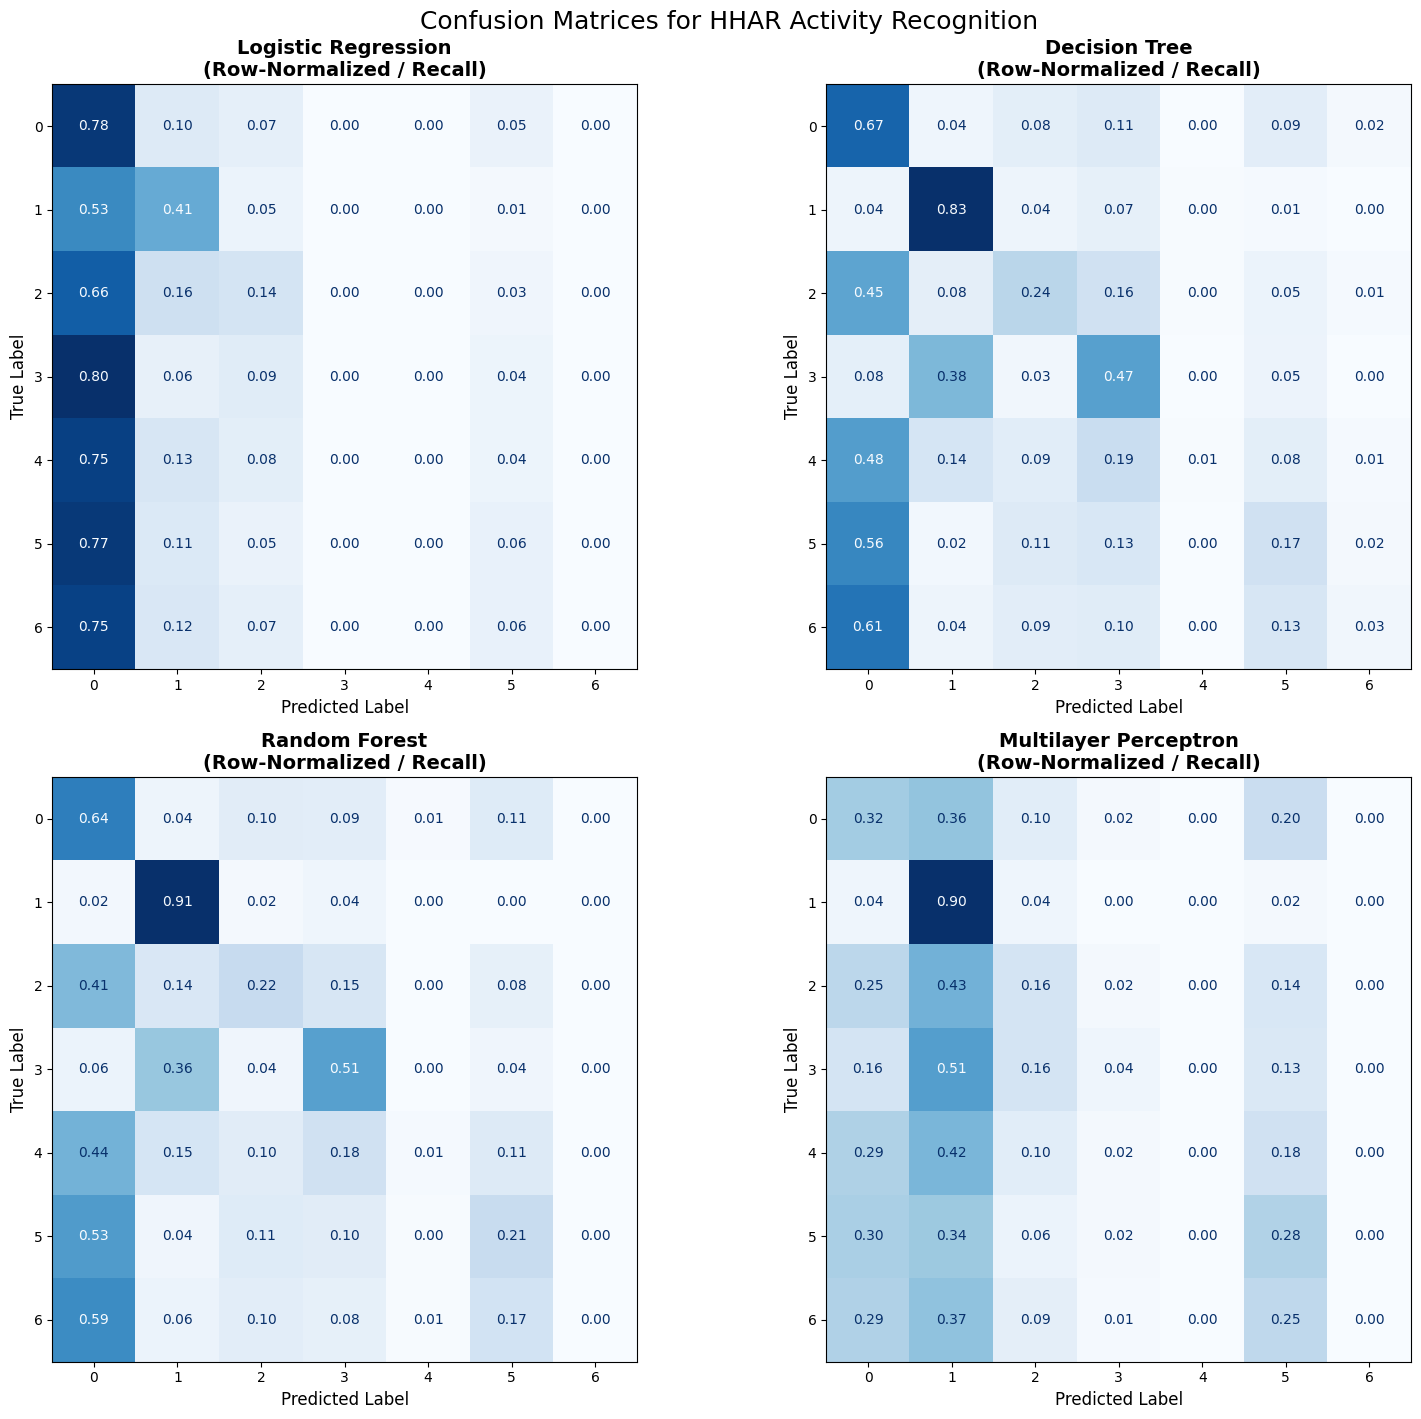

In [29]:
# CODE CELL: CONFUSION MATRICES PLOTTING
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Create a 2x2 subplot grid for the 4 models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Extract the unique integer labels present in the test set
class_labels = sorted([int(row[0]) for row in test_df.select("label").distinct().collect()])

# Optional: If you saved your StringIndexerModel from the preprocessing step (e.g., `indexer_model`),
# you can map the integers back to string names like ['Biking', 'Sitting', 'Standing', etc.]
# display_labels = indexer_model.labels
display_labels = class_labels

for i, result in enumerate(results_list):
    model_name = result["Algorithm"]
    model = result["Model_Object"]

    print(f"Generating predictions and plotting for: {model_name}...")

    # 1. Transform test data
    # 2. Select ONLY label and prediction to minimize memory footprint
    # 3. Sample 30% of the data to ensure the plot generates quickly without crashing the driver
    preds_collected = model.transform(test_df) \
                             .select("label", "prediction") \
                             .sample(0.3, seed=42) \
                             .collect()

    # Extract to standard Python lists
    y_true = [row["label"] for row in preds_collected]
    y_pred = [row["prediction"] for row in preds_collected]

    # Generate Confusion Matrix
    # normalize='true' divides each row by its sum (shows Recall / True Positive Rate per class)
    cm = confusion_matrix(y_true, y_pred, normalize='true', labels=class_labels)

    # Plot using sklearn's ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='.2f')

    axes[i].set_title(f"{model_name}\n(Row-Normalized / Recall)", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Predicted Label", fontsize=12)
    axes[i].set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.suptitle("Confusion Matrices for HHAR Activity Recognition", fontsize=18, y=1.01)
plt.show()

Generating curves for: Logistic Regression...
Generating curves for: Decision Tree...
Generating curves for: Random Forest...
Generating curves for: Multilayer Perceptron...


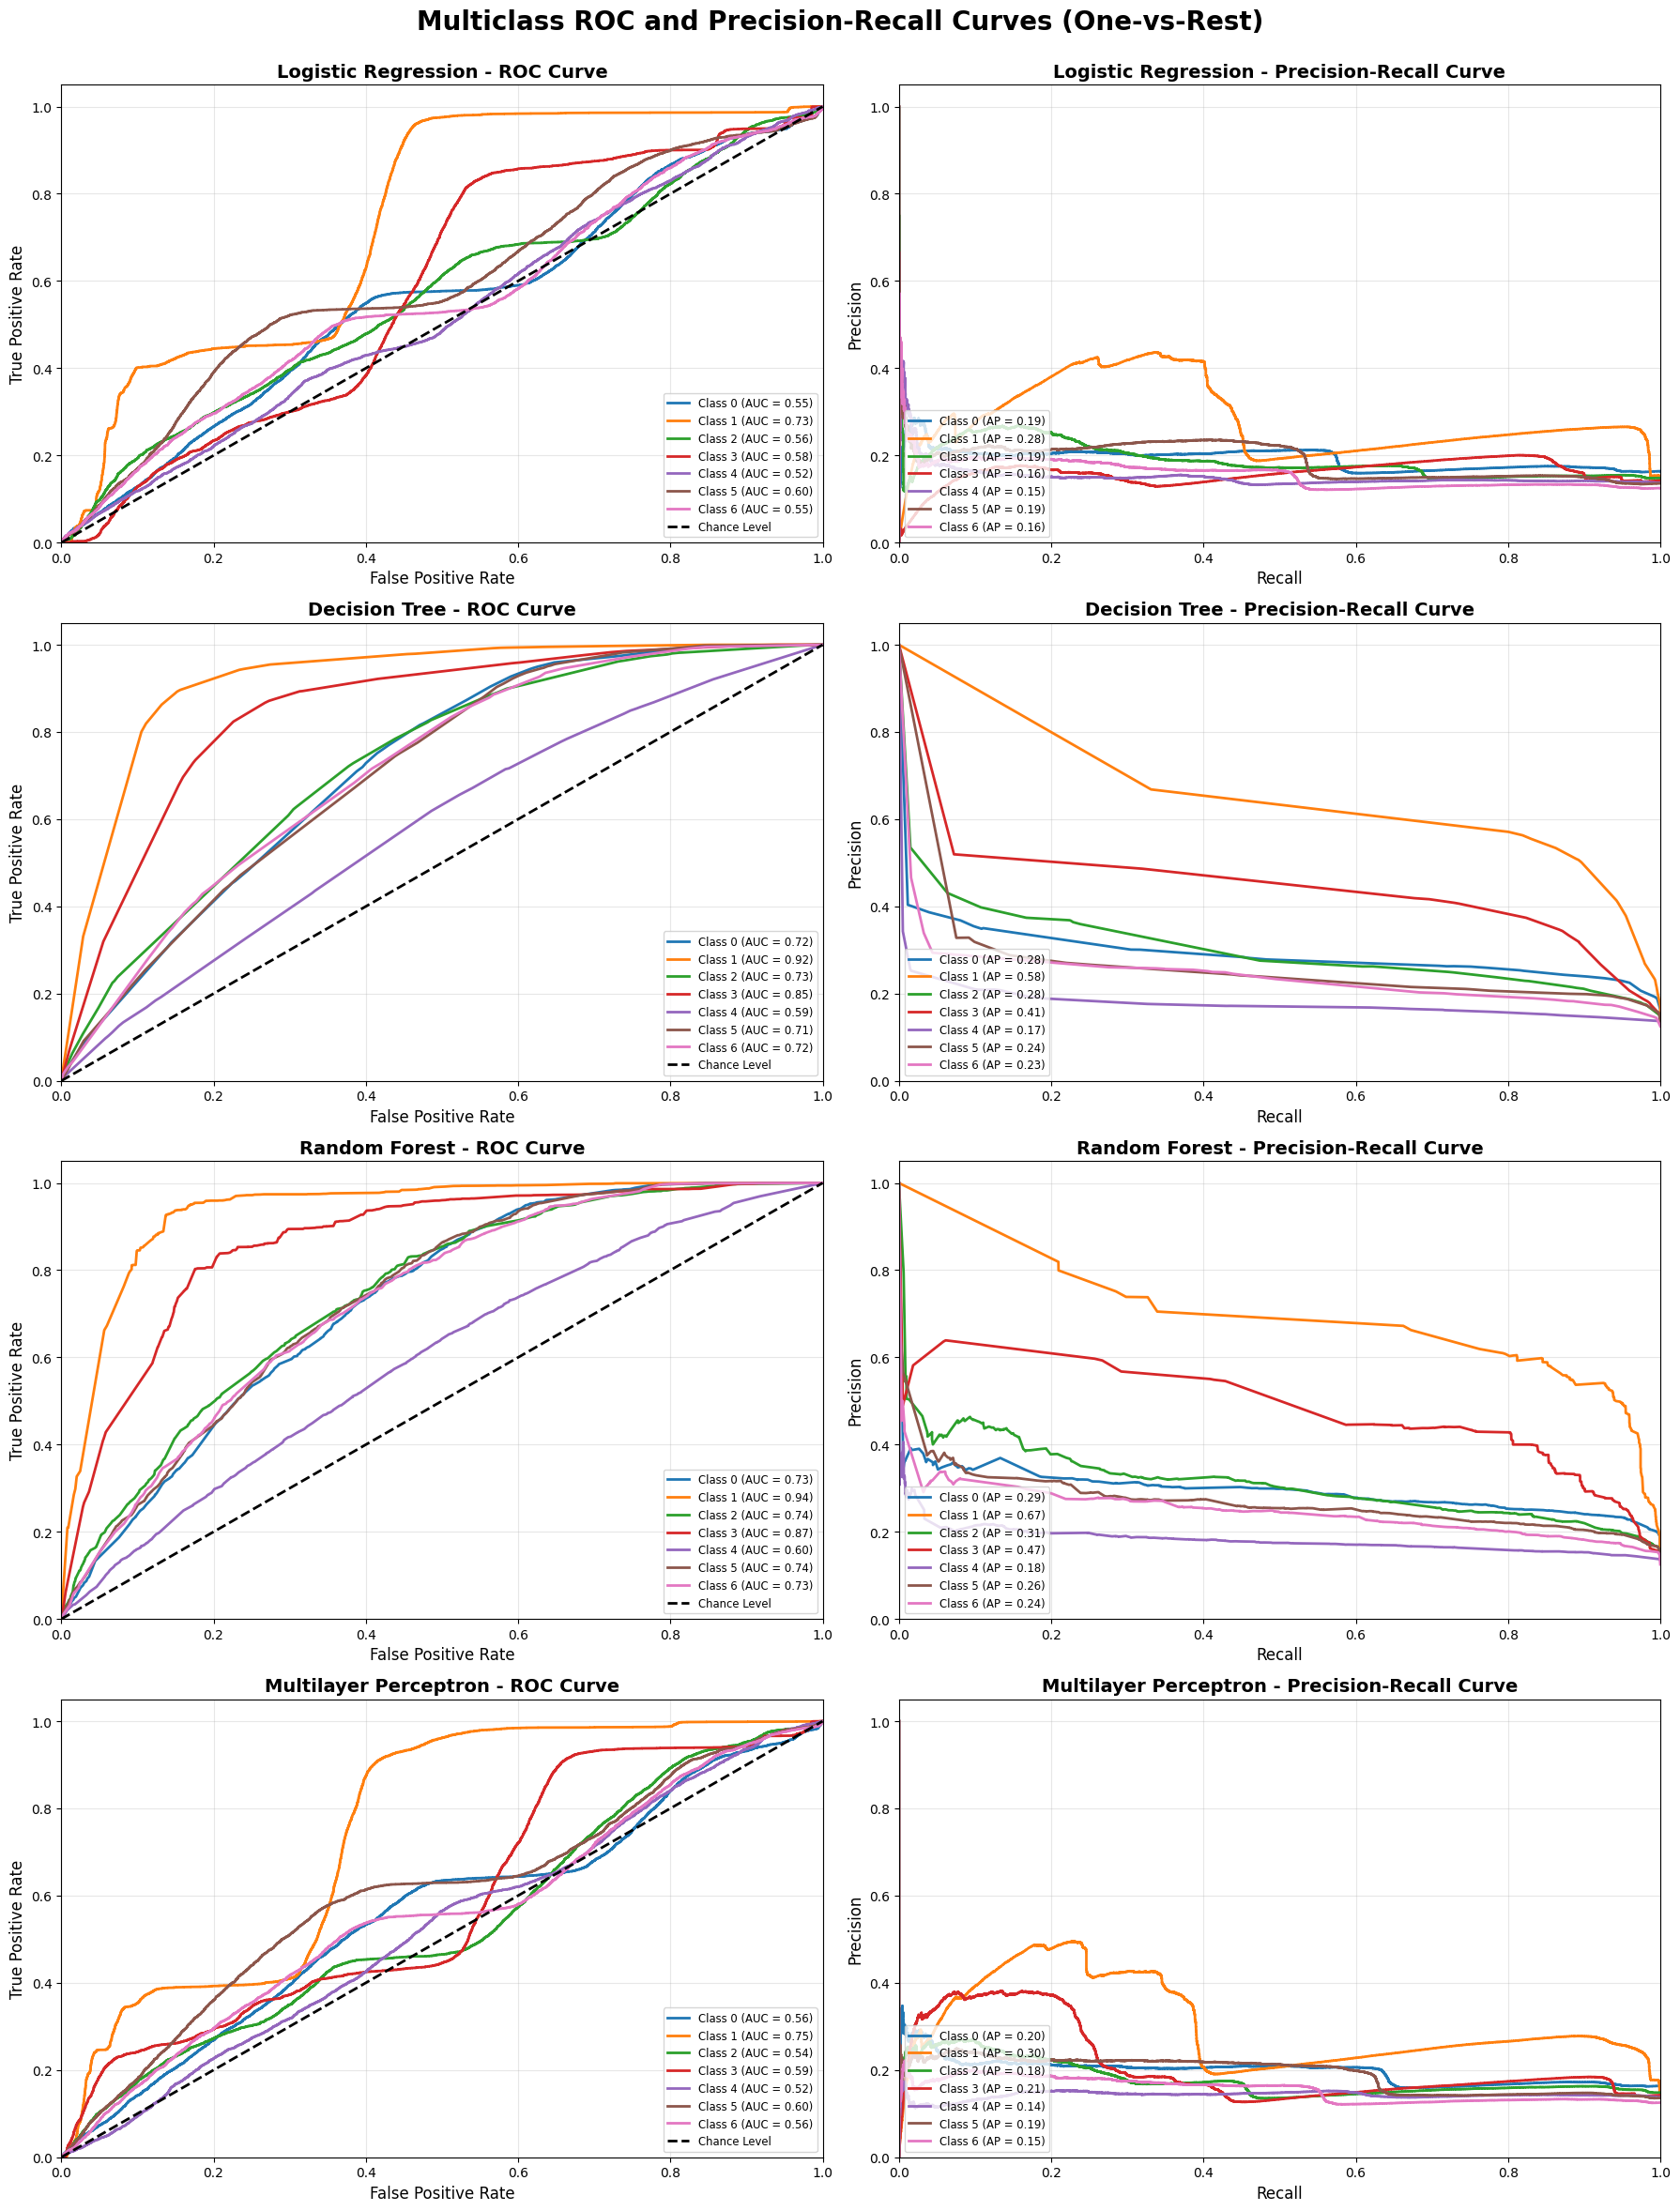

In [30]:
# CODE CELL: MULTICLASS ROC AND PR CURVES
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Determine number of classes dynamically from the test set
num_classes = int(test_df.select("label").agg({"label": "max"}).collect()[0][0]) + 1
classes = list(range(num_classes))

# Create a 4x2 subplot grid (4 models, 2 columns for ROC and PR)
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
fig.suptitle("Multiclass ROC and Precision-Recall Curves (One-vs-Rest)", fontsize=20, fontweight='bold')

for i, result in enumerate(results_list):
    model_name = result["Algorithm"]
    model = result["Model_Object"]

    print(f"Generating curves for: {model_name}...")

    # 1. Transform, Select, and Sample to prevent Driver Out-Of-Memory (OOM) errors.
    # A 5% sample of ~6.7M rows is ~335k rows, which is statistically robust and safe for memory.
    preds_collected = model.transform(test_df) \
                             .select("label", "probability") \
                             .sample(0.05, seed=42) \
                             .collect()

    # 2. Extract to NumPy arrays
    y_true = np.array([row["label"] for row in preds_collected])
    y_score = np.array([row["probability"].toArray() for row in preds_collected])

    # 3. Binarize labels for One-vs-Rest (OvR) calculation
    y_true_bin = label_binarize(y_true, classes=classes)

    # --- PLOT ROC CURVE (Left Column) ---
    ax_roc = axes[i, 0]
    for c in classes:
        fpr, tpr, _ = roc_curve(y_true_bin[:, c], y_score[:, c])
        roc_auc = auc(fpr, tpr)
        ax_roc.plot(fpr, tpr, lw=2, label=f'Class {c} (AUC = {roc_auc:.2f})')

    ax_roc.plot([0, 1], [0, 1], 'k--', lw=2, label='Chance Level')
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('False Positive Rate', fontsize=12)
    ax_roc.set_ylabel('True Positive Rate', fontsize=12)
    ax_roc.set_title(f'{model_name} - ROC Curve', fontsize=14, fontweight='bold')
    ax_roc.legend(loc="lower right", fontsize='small')
    ax_roc.grid(True, alpha=0.3)

    # --- PLOT PRECISION-RECALL CURVE (Right Column) ---
    ax_pr = axes[i, 1]
    for c in classes:
        precision, recall, _ = precision_recall_curve(y_true_bin[:, c], y_score[:, c])
        avg_prec = average_precision_score(y_true_bin[:, c], y_score[:, c])
        ax_pr.plot(recall, precision, lw=2, label=f'Class {c} (AP = {avg_prec:.2f})')

    ax_pr.set_xlim([0.0, 1.0])
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_xlabel('Recall', fontsize=12)
    ax_pr.set_ylabel('Precision', fontsize=12)
    ax_pr.set_title(f'{model_name} - Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax_pr.legend(loc="lower left", fontsize='small')
    ax_pr.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust rect to make room for suptitle
plt.show()

Preparing sampled test data for stability analysis...
Starting Stability Analysis using native Spark functions...

--- Applying Noise Level (Std Dev): 0.0 ---
  Logistic Regression: 0.2180
  Decision Tree: 0.3608
  Random Forest: 0.3787
  Multilayer Perceptron: 0.2541

--- Applying Noise Level (Std Dev): 0.1 ---
  Logistic Regression: 0.2141
  Decision Tree: 0.2663
  Random Forest: 0.2759
  Multilayer Perceptron: 0.2219

--- Applying Noise Level (Std Dev): 0.25 ---
  Logistic Regression: 0.2114
  Decision Tree: 0.2356
  Random Forest: 0.2423
  Multilayer Perceptron: 0.2159

--- Applying Noise Level (Std Dev): 0.5 ---
  Logistic Regression: 0.2052
  Decision Tree: 0.2029
  Random Forest: 0.2128
  Multilayer Perceptron: 0.2017

--- Applying Noise Level (Std Dev): 0.75 ---
  Logistic Regression: 0.1967
  Decision Tree: 0.1844
  Random Forest: 0.1971
  Multilayer Perceptron: 0.1927

--- Applying Noise Level (Std Dev): 1.0 ---
  Logistic Regression: 0.1896
  Decision Tree: 0.1734
  Random F

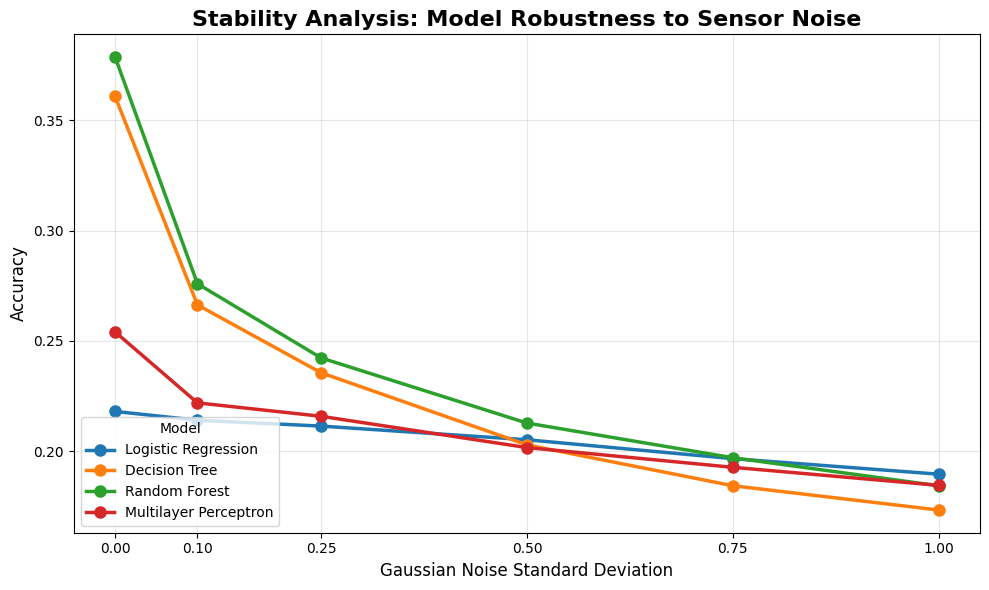

In [31]:
# CODE CELL: STABILITY ANALYSIS (PERTURBATION)
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, lit, expr
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array, array_to_vector

# 1. Sample the test data
print("Preparing sampled test data for stability analysis...")
test_sample = test_df.select("label", "scaledFeatures").sample(0.1, seed=42).cache()
test_sample.count()

# 2. Define noise levels
noise_levels = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
stability_results = {result["Algorithm"]: [] for result in results_list}

print("Starting Stability Analysis using native Spark functions...")
for noise in noise_levels:
    print(f"\n--- Applying Noise Level (Std Dev): {noise} ---")

    if noise == 0.0:
        perturbed_df = test_sample
    else:
        # Native Spark Implementation:
        # 1. Convert vector to array
        # 2. Add random normal noise to each element of the array
        # 3. Convert back to vector
        perturbed_df = test_sample.withColumn("arr", vector_to_array("scaledFeatures")) \
            .withColumn("noisy_arr", expr(f"transform(arr, x -> x + randn() * {noise})")) \
            .withColumn("perturbedFeatures", array_to_vector("noisy_arr")) \
            .drop("scaledFeatures", "arr", "noisy_arr") \
            .withColumnRenamed("perturbedFeatures", "scaledFeatures")

    for result in results_list:
        model_name = result["Algorithm"]
        model = result["Model_Object"]

        preds = model.transform(perturbed_df)
        acc = evaluator.evaluate(preds)
        stability_results[model_name].append(acc)
        print(f"  {model_name}: {acc:.4f}")

# 3. Plotting
plt.figure(figsize=(10, 6))
for model_name, accs in stability_results.items():
    plt.plot(noise_levels, accs, marker='o', linewidth=2.5, markersize=8, label=model_name)

plt.title("Stability Analysis: Model Robustness to Sensor Noise", fontsize=16, fontweight='bold')
plt.xlabel("Gaussian Noise Standard Deviation", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(noise_levels)
plt.legend(title="Model", loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Model Explainability for: Random Forest ---
1. Sampling data and generating PySpark predictions...
2. Training Scikit-Learn Surrogate Model...
Surrogate Fidelity: 100.00%

3. Computing SHAP values...
4. Generating Explainability Plots...


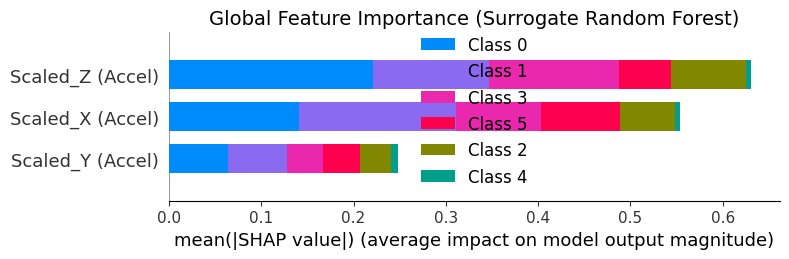

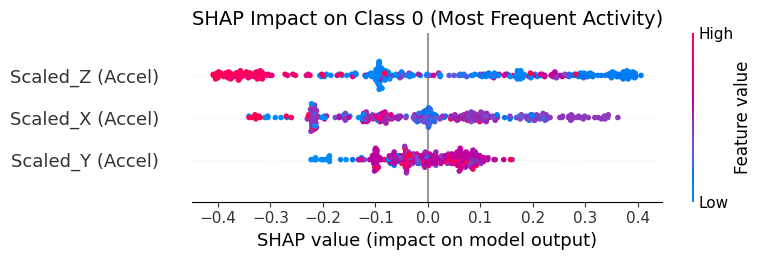

<Figure size 1000x400 with 0 Axes>

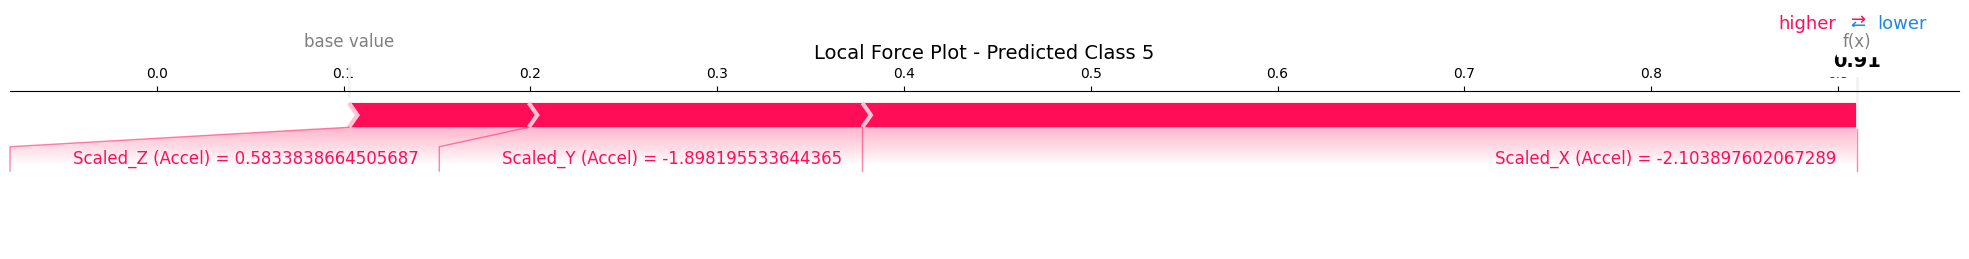

In [32]:
# CODE CELL: MODEL EXPLAINABILITY (SHAP)
import shap
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# We will explain the PySpark Random Forest model
target_model_result = next(r for r in results_list if r["Algorithm"] == "Random Forest")
spark_model = target_model_result["Model_Object"]
model_name = target_model_result["Algorithm"]

print(f"--- Model Explainability for: {model_name} ---")
print("1. Sampling data and generating PySpark predictions...")
sample_spark = test_df.select("scaledFeatures", "label").sample(fraction=0.0005, seed=42).limit(2000)
sample_with_preds = spark_model.transform(sample_spark)

pdf = sample_with_preds.select("scaledFeatures", "label", "prediction").toPandas()
X_np = np.array([v.toArray() for v in pdf["scaledFeatures"]])
y_spark_pred = pdf["prediction"].values

print("2. Training Scikit-Learn Surrogate Model...")
surrogate = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
surrogate.fit(X_np, y_spark_pred)

fidelity = accuracy_score(y_spark_pred, surrogate.predict(X_np))
print(f"Surrogate Fidelity: {fidelity:.2%}\n")

print("3. Computing SHAP values...")
explainer = shap.TreeExplainer(surrogate)
shap_values = explainer.shap_values(X_np, check_additivity=False)

print("4. Generating Explainability Plots...")
feature_names = ["Scaled_X (Accel)", "Scaled_Y (Accel)", "Scaled_Z (Accel)"]

# Robust handling for multiclass SHAP structures
if isinstance(shap_values, list):
    # List-based output (older SHAP version or specific models)
    shap_values_class0 = shap_values[0]
    shap_values_global = shap_values
else:
    # 3D array [instances, features, classes] or [instances, classes, features]
    # Check shape to orient correctly
    if shap_values.shape[1] == len(feature_names):
        # Shape is (instances, features, classes)
        shap_values_class0 = shap_values[:, :, 0]
        shap_values_global = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    else:
        # Shape is (instances, classes, features)
        shap_values_class0 = shap_values[:, 0, :]
        shap_values_global = [shap_values[:, i, :] for i in range(shap_values.shape[1])]

# --- PLOT 1: Global Feature Importance ---
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_global, X_np, feature_names=feature_names, plot_type="bar", show=False)
plt.title(f"Global Feature Importance (Surrogate {model_name})", fontsize=14)
plt.tight_layout()
plt.show()

# --- PLOT 2: SHAP Beeswarm Plot (Class 0) ---
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_class0, X_np, feature_names=feature_names, show=False)
plt.title(f"SHAP Impact on Class 0 (Most Frequent Activity)", fontsize=14)
plt.tight_layout()
plt.show()

# --- PLOT 3: Local Force Plot (First Instance) ---
instance_idx = 0
predicted_class = int(y_spark_pred[instance_idx])
plt.figure(figsize=(10, 4))
shap.force_plot(
    explainer.expected_value[predicted_class],
    shap_values_global[predicted_class][instance_idx],
    X_np[instance_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f"Local Force Plot - Predicted Class {predicted_class}", fontsize=14)
plt.tight_layout()
plt.show()